
Running Hybrid Fusion Model on 80 images...
  Processing batch 1...
  Processing batch 2...
  Processing batch 3...
  Processing batch 4...
  Processing batch 5...
  Processing batch 6...
  Processing batch 7...
  Processing batch 8...

 HYBRID MODEL: PERFORMANCE RESULTS
Image      Accuracy     Sensitivity  Precision    Specificity  F1-Score    
-----------------------------------------------------------------------------------------------
0             95.43       66.13       89.12       99.01       75.92
1             94.72       58.10       88.49       99.10       70.15
2             95.69       55.58       87.51       99.29       67.98
3             92.77       53.00       92.08       99.26       67.28
4             94.21       50.36       96.14       99.74       66.10
5             93.58       49.16       96.07       99.72       65.04
6             93.46       52.44       83.82       98.71       64.52
7             92.66       53.77       79.99       98.11       64.31
8          

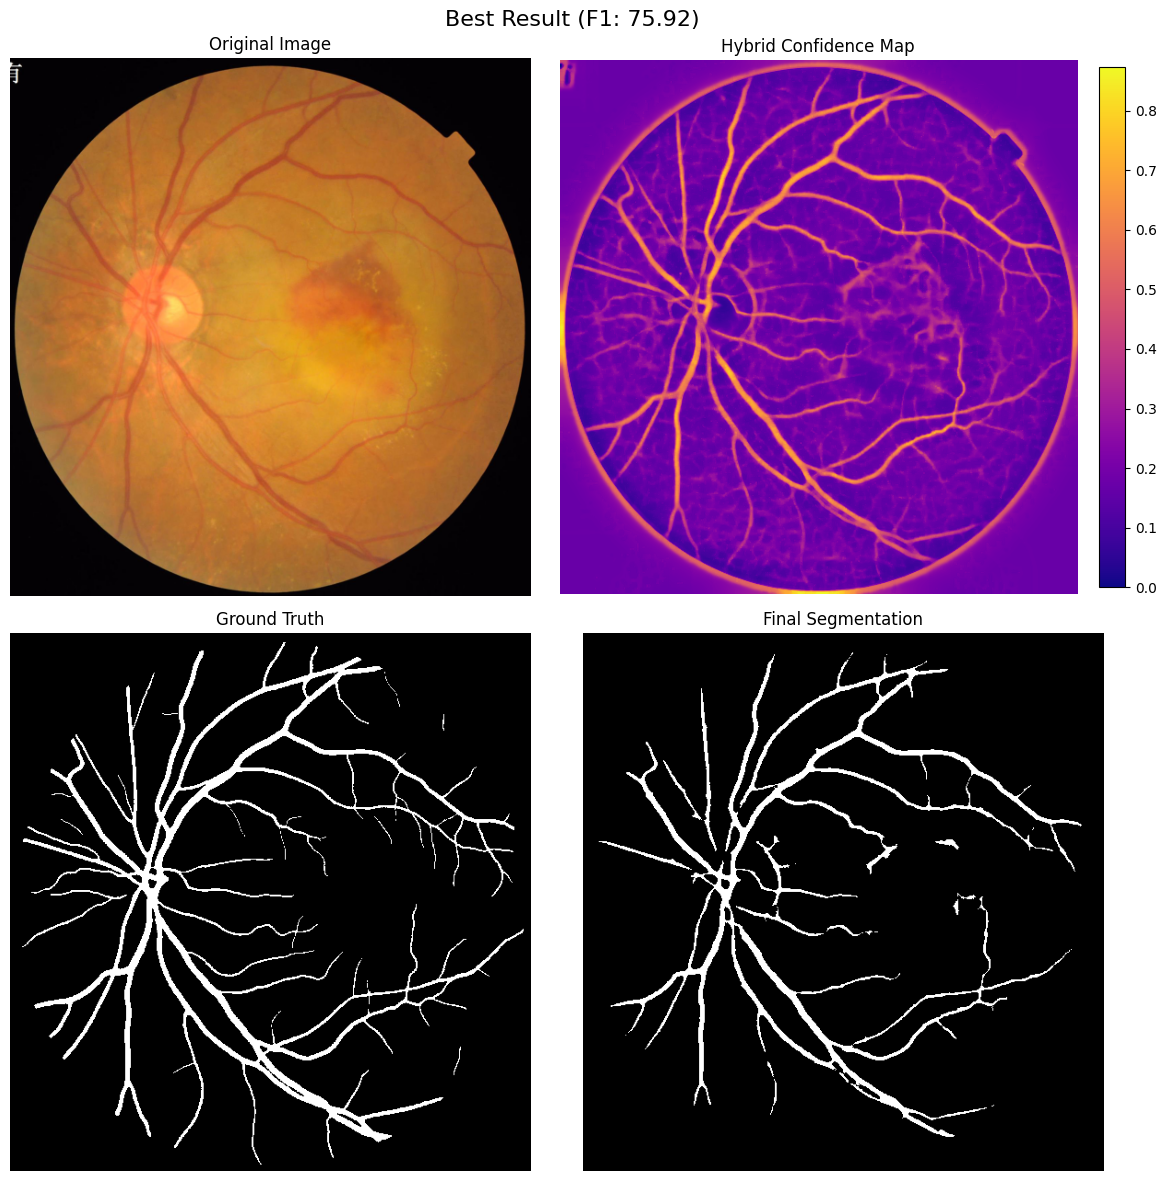

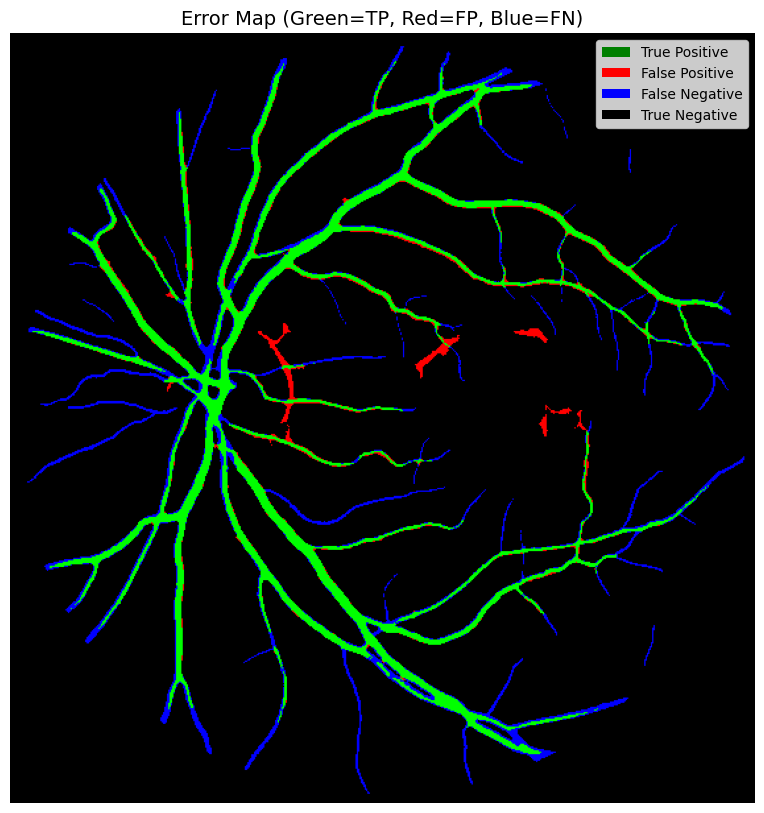

In [23]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc
from matplotlib.patches import Patch

# =====================================================================
# IMPORT MODULES
# =====================================================================
from preprocess import preprocess
import matched
import scale_space
import line_detection
import morphological

# =====================================================================
# 1. UTILITIES
# =====================================================================

def get_file_paths(folder_path, max_images=None):
    if not os.path.exists(folder_path): return []
    all_files = sorted(os.listdir(folder_path))
    if max_images: all_files = all_files[:max_images]
    valid_exts = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
    return [os.path.join(folder_path, f) for f in all_files if f.lower().endswith(valid_exts)]

def load_batch(file_paths):
    images = []
    for fp in file_paths:
        img = cv2.imread(fp)
        if img is not None: images.append(img)
    return images

def get_FOV_masks(dataset):
    masks = []
    for img in dataset:
        if len(img.shape) == 3: src = img[:,:,1]
        else: src = img
        _, binary = cv2.threshold(src, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        mask = np.zeros_like(src)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)
        masks.append((mask // 255).astype(np.uint8))
    return masks

# =====================================================================
# 2. POST-PROCESSING (Standardized)
# =====================================================================

def post_process_segmentation(probability_map, threshold=0.08, min_area=100):
    # Thresholding
    binary_map = (probability_map > threshold).astype(np.uint8)
    
    # Morphological Closing
    kernel = np.ones((2, 2), np.uint8)
    binary_map = cv2.morphologyEx(binary_map, cv2.MORPH_CLOSE, kernel)
    
    # CCA
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_map, connectivity=8)
    clean_mask = np.zeros_like(binary_map)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean_mask[labels == i] = 1
            
    return probability_map * clean_mask

# =====================================================================
# 3. METRICS
# =====================================================================

def calculate_metrics(pred_map, ground_truth, mask, threshold):
    gt_binary = (ground_truth > 127).astype(bool)
    pred_binary = (pred_map > threshold).astype(bool)
    fov_mask = mask.astype(bool)

    gt_binary &= fov_mask
    pred_binary &= fov_mask

    TP = np.sum(gt_binary & pred_binary)
    TN = np.sum(~gt_binary & ~pred_binary & fov_mask)
    FP = np.sum(~gt_binary & pred_binary)
    FN = np.sum(gt_binary & ~pred_binary)

    denom = TP + TN + FP + FN
    # Multiply metrics by 100 for percentage representation
    accuracy = ((TP + TN) / denom) * 100.0 if denom > 0 else 0.0
    sensitivity = (TP / (TP + FN)) * 100.0 if (TP + FN) > 0 else 0.0
    specificity = (TN / (TN + FP)) * 100.0 if (TN + FP) > 0 else 0.0
    precision = (TP / (TP + FP)) * 100.0 if (TP + FP) > 0 else 0.0
    
    f1_score = 0.0
    if (precision + sensitivity) > 0:
        f1_score = 2.0 * (precision * sensitivity) / (precision + sensitivity)

    return {
        "accuracy": accuracy, "sensitivity": sensitivity,
        "specificity": specificity, "precision": precision,
        "f1_score": f1_score, "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

# =====================================================================
# 4. HYBRID PROCESSING CONTROLLER
# =====================================================================

def process_dataset_hybrid(img_paths, gt_paths, batch_size=5, sensitivity=0.08):
    total_images = len(img_paths)
    all_metrics = []
    best_overall_data = None
    best_overall_f1 = -1.0
    
    print(f"\nRunning Hybrid Fusion Model on {total_images} images...")

    for i in range(0, total_images, batch_size):
        # 1. Load Batch
        current_imgs = load_batch(img_paths[i:i+batch_size])
        current_gts = load_batch(gt_paths[i:i+batch_size])
        if not current_imgs: continue
        
        print(f"  Processing batch {i//batch_size + 1}...")
        
        # 2. Global Preprocessing
        preprocessed_batch = preprocess(current_imgs)
        
        # 3. Run Individual Algorithms
        conf_matched = matched.matched_filter(preprocessed_batch)
        conf_scale = scale_space.scale_space(preprocessed_batch)
        conf_line = line_detection.line_detection(preprocessed_batch)
        conf_morph = morphological.morphological(preprocessed_batch)
        
        batch_fovs = get_FOV_masks(current_imgs)
        
        # 4. Fusion & Evaluation
        for k in range(len(current_imgs)):
            hybrid_conf = (
                0.25*conf_matched[k] + 
                0.25*conf_scale[k] + 
                0.25*conf_line[k] + 
                0.25*conf_morph[k]
            ) 
            
            # Apply FOV
            masked_conf = hybrid_conf * batch_fovs[k]
            
            # Post-Process
            final_map = post_process_segmentation(masked_conf, threshold=sensitivity)
            
            # Metrics
            gt_gray = cv2.cvtColor(current_gts[k], cv2.COLOR_BGR2GRAY)
            m = calculate_metrics(final_map, gt_gray, batch_fovs[k], sensitivity)
            m['filename'] = os.path.basename(img_paths[i+k])
            all_metrics.append(m)
            
            # Track Best
            if m['f1_score'] > best_overall_f1:
                best_overall_f1 = m['f1_score']
                best_overall_data = {
                    'original': current_imgs[k].copy(),
                    'confidence': hybrid_conf.copy(),
                    'binary': (final_map > sensitivity).astype(np.uint8) * 255,
                    'gt': current_gts[k].copy(),
                    'mask': batch_fovs[k].copy(),
                    'metrics': m
                }
        
        # Clean memory
        del current_imgs, current_gts, preprocessed_batch
        del conf_matched, conf_scale, conf_line, conf_morph
        gc.collect()
        
    return all_metrics, best_overall_data

# =====================================================================
# 5. VISUALIZATION & REPORTING
# =====================================================================

def plot_results(data):
    if not data: return
    
    img_rgb = cv2.cvtColor(data['original'], cv2.COLOR_BGR2RGB)
    conf_map = data['confidence']
    binary_map = data['binary']
    gt_gray = cv2.cvtColor(data['gt'], cv2.COLOR_BGR2GRAY)
    mask = data['mask']
    m = data['metrics']
    
    # --- Figure 1: 2x2 Overview ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    # Title without filename, just rank/score
    plt.suptitle(f"Best Result (F1: {m['f1_score']:.2f})", fontsize=16)
    
    axes[0,0].imshow(img_rgb)
    axes[0,0].set_title("Original Image")
    axes[0,0].axis('off')
    
    im1 = axes[0,1].imshow(conf_map, cmap='plasma')
    axes[0,1].set_title("Hybrid Confidence Map")
    axes[0,1].axis('off')
    plt.colorbar(im1, ax=axes[0,1], fraction=0.046, pad=0.04)
    
    axes[1,0].imshow(gt_gray, cmap='gray')
    axes[1,0].set_title("Ground Truth")
    axes[1,0].axis('off')
    
    axes[1,1].imshow(binary_map, cmap='gray')
    # Removed threshold mention as requested
    axes[1,1].set_title(f"Final Segmentation")
    axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # --- Figure 2: Error Map ---
    gt_bool = (gt_gray > 127) & (mask > 0)
    pred_bool = (binary_map > 127) & (mask > 0)
    
    TP = gt_bool & pred_bool
    FP = (~gt_bool) & pred_bool
    FN = gt_bool & (~pred_bool)
    
    error_viz = np.zeros((gt_gray.shape[0], gt_gray.shape[1], 3), dtype=np.uint8)
    error_viz[TP] = [0, 255, 0] # Green
    error_viz[FP] = [255, 0, 0] # Red
    error_viz[FN] = [0, 0, 255] # Blue
    
    plt.figure(figsize=(10, 10))
    plt.imshow(error_viz)
    plt.title(f"Error Map (Green=TP, Red=FP, Blue=FN)", fontsize=14)
    plt.axis('off')
    
    legend_elements = [
        Patch(facecolor='green', label='True Positive'),
        Patch(facecolor='red', label='False Positive'),
        Patch(facecolor='blue', label='False Negative'),
        Patch(facecolor='black', label='True Negative')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()

def print_metrics(metrics):
    # Sort by F1 Score descending to find the best images
    sorted_metrics = sorted(metrics, key=lambda x: x['f1_score'], reverse=True)
    
    # Slice only the top 20
    top_20 = sorted_metrics[:20]
    
    print("\n" + "="*95)
    print(f" HYBRID MODEL: PERFORMANCE RESULTS")
    print("="*95)
    # Added F1-Score to the header and fixed column alignment
    print(f"{'Image':<10} {'Accuracy':<12} {'Sensitivity':<12} {'Precision':<12} {'Specificity':<12} {'F1-Score':<12}")
    print("-" * 95)
    
    accs, sens, specs, precs, f1s = [], [], [], [], []
    
    for i, m in enumerate(top_20):
        # Use filename if available, otherwise use rank
        label = m.get('filename', f"{i+1:02d}")
        # specific handling to keep table clean if filenames are long
        if len(label) > 10: label = label[-10:] 
        
        acc = m['accuracy']
        sen = m['sensitivity']
        prec = m['precision']
        spec = m['specificity']
        f1 = m['f1_score']
        
        accs.append(acc)
        sens.append(sen)
        specs.append(spec)
        precs.append(prec)
        f1s.append(f1)
        
        # Print row with consistent formatting
        print(f"{i:<10} {acc:>8.2f}    {sen:>8.2f}    {prec:>8.2f}    {spec:>8.2f}    {f1:>8.2f}")
        
    print("-" * 95)
    # Calculate Mean only for the top 20 images displayed above
    print(f"{'Mean':<10} {np.mean(accs):>8.2f}    {np.mean(sens):>8.2f}    {np.mean(precs):>8.2f}    {np.mean(specs):>8.2f}    {np.mean(f1s):>8.2f}")
    print("="*95)
# =====================================================================
# MAIN
# =====================================================================

if __name__ == "__main__":
    # Parameters
    SENSITIVITY_THRESHOLD = 0.35 # Kept low to ensure high sensitivity
    BATCH_SIZE = 10               # Adjust based on memory
    
    base_dir = "dataset"
    train_orig = os.path.join(base_dir, "train", "Original")
    train_gt = os.path.join(base_dir, "train", "Ground truth")
    
    # Load Paths
    img_paths = get_file_paths(train_orig, max_images=80)
    gt_paths = get_file_paths(train_gt, max_images=80)
    
    if img_paths:
        metrics, best_data = process_dataset_hybrid(
            img_paths, 
            gt_paths, 
            batch_size=BATCH_SIZE, 
            sensitivity=SENSITIVITY_THRESHOLD
        )
        
        if metrics:
            print_metrics(metrics)
            
        if best_data:
            print("\nDisplaying results for best image...")
            plot_results(best_data)
    else:
        print("No images found.")